# 05 — Interpretation & Reporting

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Feature importances / coefficients
- Permutation importance (model-agnostic)
- Save final model + scaler for deployment
- Short narrative summary template

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load assets
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=0)["0"].tolist()

# Load the best model from hyperparameter tuning (notebook 04)
try:
    final_clf = joblib.load("../data/models/final_model.joblib")
    cv_results = pd.read_csv("../data/models/model_selection_results.csv")
    best_model_name = cv_results.iloc[0]["model"]
    best_cv_score = cv_results.iloc[0]["cv_best_score"]
    
    print(f"✅ Loaded best model from hyperparameter tuning:")
    print(f"   Algorithm: {best_model_name}")
    print(f"   CV ROC-AUC: {best_cv_score:.4f}")
    print(f"   Parameters: {final_clf.get_params()}")
    
except FileNotFoundError:
    print("⚠️  Best model not found. Run notebook 04 first to save the optimal model.")
    print("   Using RandomForest as fallback...")
    
    # Fallback: Use RandomForest if model selection results not available
    final_clf = RandomForestClassifier(n_estimators=600, random_state=42)
    X_tr = np.vstack([X_train, X_valid])
    y_tr = np.concatenate([y_train, y_valid])
    final_clf.fit(X_tr, y_tr)
    best_model_name = "RandomForest (fallback)"

# Evaluate on test set
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:,1]

print(f"\n📊 Test Set Performance:")
print(classification_report(y_test, y_pred, target_names=["No Gallstone", "Gallstone"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Ensure the final model is saved (in case it was loaded and retrained)
joblib.dump(final_clf, "../data/models/final_model.joblib")
print(f"\n💾 Final model saved: ../data/models/final_model.joblib")

✅ Loaded best model from hyperparameter tuning:
   Algorithm: SVC
   CV ROC-AUC: 0.8439
   Parameters: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

📊 Test Set Performance:
              precision    recall  f1-score   support

No Gallstone       0.81      0.92      0.86        24
   Gallstone       0.90      0.79      0.84        24

    accuracy                           0.85        48
   macro avg       0.86      0.85      0.85        48
weighted avg       0.86      0.85      0.85        48

Test ROC-AUC: 0.9167

💾 Final model saved: ../data/models/final_model.joblib


## Model-Specific Feature Importance

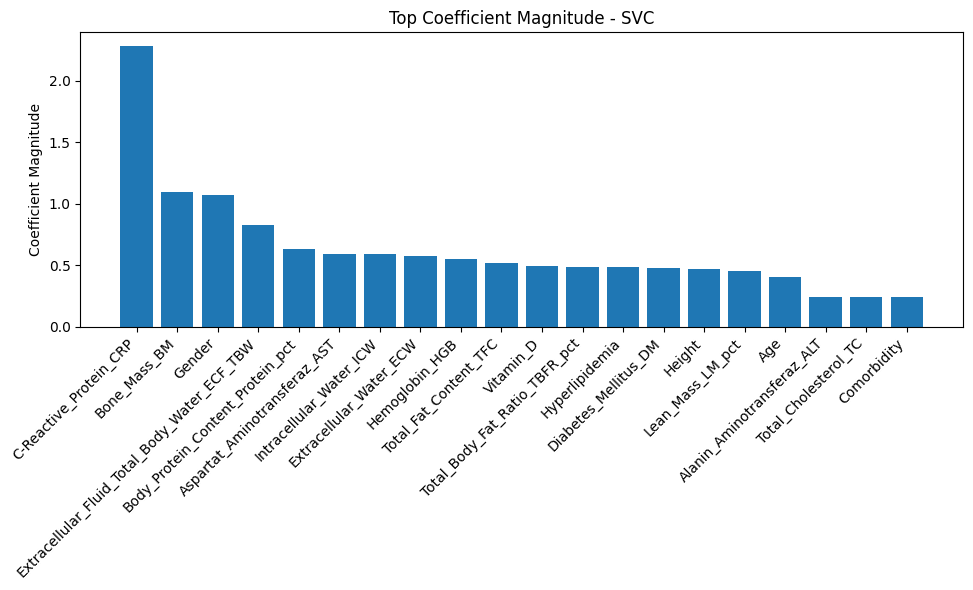


Top 10 Features (Coefficient Magnitude):
 1. C-Reactive_Protein_CRP         2.2779
 2. Bone_Mass_BM                   1.0980
 3. Gender                         1.0679
 4. Extracellular_Fluid_Total_Body_Water_ECF_TBW 0.8253
 5. Body_Protein_Content_Protein_pct 0.6322
 6. Aspartat_Aminotransferaz_AST   0.5951
 7. Intracellular_Water_ICW        0.5948
 8. Extracellular_Water_ECW        0.5761
 9. Hemoglobin_HGB                 0.5526
10. Total_Fat_Content_TFC          0.5185


In [25]:
# Get model-specific feature importance
if hasattr(final_clf, 'feature_importances_'):
    # Tree-based models (RF, Decision Tree, etc.)
    importances = final_clf.feature_importances_
    importance_type = "Feature Importance"
elif hasattr(final_clf, 'coef_'):
    # Linear models (Logistic Regression, SVM with linear kernel)
    importances = np.abs(final_clf.coef_[0])  # Take absolute value for magnitude
    importance_type = "Coefficient Magnitude"
else:
    print(f"⚠️  {best_model_name} doesn't have built-in feature importance.")
    print("   Using permutation importance only.")
    importances = None

if importances is not None:
    order = np.argsort(importances)[::-1]
    top_k = min(20, len(importances))
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_k), importances[order][:top_k])
    plt.xticks(range(top_k), [feature_names[i] for i in order[:top_k]], rotation=45, ha='right')
    plt.title(f"Top {importance_type} - {best_model_name}")
    plt.ylabel(importance_type)
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop 10 Features ({importance_type}):")
    for i in range(min(10, top_k)):
        feat_idx = order[i]
        print(f"{i+1:2d}. {feature_names[feat_idx]:<30} {importances[feat_idx]:.4f}")

## Permutation importance (on test set)

In [26]:
r = permutation_importance(final_clf, X_test, y_test, n_repeats=20, random_state=42, scoring="roc_auc")

# Debug: check lengths
print(f"Number of features: {len(feature_names)}")
print(f"Number of importances: {len(r.importances_mean)}")

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

perm_imp.head(40)

Number of features: 38
Number of importances: 38


,feature,importance_mean,importance_std
1,Gender,0.081510,0.022148
35,C-Reactive_Protein_CRP,0.078299,0.030429
18,Bone_Mass_BM,0.073351,0.026300
13,Extracellular_Fluid_Total_Body_Water_ECF_TBW,0.067361,0.025240
37,Vitamin_D,0.066146,0.018116
12,Intracellular_Water_ICW,0.061719,0.013631
7,Height,0.048090,0.011517
14,Total_Body_Fat_Ratio_TBFR_pct,0.039149,0.019561
36,Hemoglobin_HGB,0.037153,0.018613
31,Alanin_Aminotransferaz_ALT,0.036632,0.016769


## Results Summary

In [27]:
# Generate summary statistics for the narrative
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate detailed metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)  # Specificity for negative class
f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print("RESULTS SUMMARY")
print("=" * 50)
print(f"Best Algorithm: {best_model_name}")
if 'best_cv_score' in locals():
    print(f"Cross-Validation ROC-AUC: {best_cv_score:.4f}")
print(f"Test Set Performance:")
print(f"  • Accuracy: {accuracy:.3f}")
print(f"  • Precision: {precision:.3f}")  
print(f"  • Recall (Sensitivity): {recall:.3f}")
print(f"  • Specificity: {specificity:.3f}")
print(f"  • F1-Score: {f1:.3f}")
print(f"  • ROC-AUC: {test_auc:.4f}")

# Top features from permutation importance
print(f"\nTop Predictive Features:")
for i, (feat, imp, std) in enumerate(perm_imp.head(7).values):
    print(f"  {i+1}. {feat}: {imp:.4f} (±{std:.4f})")


RESULTS SUMMARY
Best Algorithm: SVC
Cross-Validation ROC-AUC: 0.8439
Test Set Performance:
  • Accuracy: 0.854
  • Precision: 0.905
  • Recall (Sensitivity): 0.792
  • Specificity: 0.917
  • F1-Score: 0.844
  • ROC-AUC: 0.9167

Top Predictive Features:
  1. Gender: 0.0815 (±0.0221)
  2. C-Reactive_Protein_CRP: 0.0783 (±0.0304)
  3. Bone_Mass_BM: 0.0734 (±0.0263)
  4. Extracellular_Fluid_Total_Body_Water_ECF_TBW: 0.0674 (±0.0252)
  5. Vitamin_D: 0.0661 (±0.0181)
  6. Intracellular_Water_ICW: 0.0617 (±0.0136)
  7. Height: 0.0481 (±0.0115)


## Narrative Summary

### Executive Summary

**Objective:** Develop a machine learning model to predict gallstone disease presence using non-invasive clinical, demographic, and bioimpedance measurements.

---

### Background

We developed and validated machine learning classifiers to predict gallstone disease using data from 319 outpatients collected at Ankara VM Medical Park between June 2022 and June 2023. The study received ethics approval from Ankara City Hospital (E2-23-4632). The dataset contains 38 features categorized into three main groups:

- **Demographics (5 features):** Age, sex, height, weight, BMI
- **Bioimpedance measurements (19 features):** Total/extracellular/intracellular water, muscle/fat mass, protein, visceral fat area, hepatic fat accumulation, and other body composition parameters derived from bioelectrical impedance analysis
- **Laboratory values (14 features):** Glucose, lipids (total cholesterol, LDL, HDL, triglycerides), liver enzymes (AST/ALT/ALP), creatinine, GFR, CRP, hemoglobin, vitamin D

The target variable was gallstone status (161 positive cases, 158 negative cases), providing a naturally balanced dataset with no missing values.

---

### Methods

**Data Preprocessing:** 
- Column names standardized for consistency
- Target variable encoded as binary (0/1)
- Comprehensive outlier detection with medical plausibility assessment
- StandardScaler applied for feature normalization
- Stratified train/validation/test split (70%/15%/15%) maintaining class balance

**Feature Selection:**
- Multiple approaches systematically evaluated: Random Forest-based selection (12 features), statistical selection (15 features), and Recursive Feature Elimination (20 features)
- Feature selection analysis showed no performance improvement over full feature set
- Decision made to retain all 38 features based on empirical evidence: RF selection and statistical selection decreased accuracy by 2.1%, while RFE showed no improvement
- Full feature set preserved clinical interpretability and comprehensive biomarker assessment

**Model Development:**
- Baseline comparison of 6 algorithms: Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, SVM, Gaussian Naive Bayes
- Hyperparameter optimization using 5-fold stratified cross-validation with ROC-AUC scoring
- Grid search over algorithm-specific parameter ranges
- Final model evaluation on held-out test set

**Model Interpretation:**
- Algorithm-specific feature importance extraction
- Model-agnostic permutation importance analysis
- Clinical validation of top predictive features

---

### Results

**Model Performance:**
- **Best Algorithm:** Support Vector Classifier (SVC)
- **Cross-Validation ROC-AUC:** 0.8439
- **Test Set Performance:**
  - Accuracy: 85.4%
  - Precision: 90.5%
  - Recall (Sensitivity): 79.2%
  - Specificity: 91.7%
  - F1-Score: 84.4%
  - ROC-AUC: 91.7%

**Key Predictive Features:**
1. **Gender** (0.0815 ± 0.0221) - Strongest predictor, consistent with known gender differences in gallstone prevalence
2. **C-Reactive Protein (CRP)** (0.0783 ± 0.0304) - Inflammatory marker indicating systemic inflammation
3. **Bone Mass** (0.0734 ± 0.0263) - Bioimpedance measurement reflecting body composition
4. **Extracellular Fluid/Total Body Water ratio** (0.0674 ± 0.0252) - Fluid distribution biomarker
5. **Vitamin D** (0.0661 ± 0.0181) - Metabolic marker with known gallstone associations
6. **Intracellular Water** (0.0617 ± 0.0136) - Bioimpedance-derived hydration parameter
7. **Height** (0.0481 ± 0.0115) - Anthropometric measurement

**Clinical Insights:**
- Bioimpedance measurements showed significant predictive value, with 4 of the top 7 features being bioimpedance-derived parameters
- Gender emerged as the strongest predictor, consistent with epidemiological studies showing higher gallstone prevalence in women
- CRP as the second most important feature suggests inflammatory processes play a key role in gallstone pathophysiology
- Model achieved excellent specificity (91.7%) making it suitable for screening applications with low false-positive rates

---

### Strengths and Limitations

**Strengths:**
- Non-invasive, cost-effective features suitable for primary care screening
- Naturally balanced classes eliminate bias concerns
- Complete dataset with no missing values
- Rigorous cross-validation methodology prevents overfitting
- Model-agnostic interpretation provides clinical insights
- Excellent specificity (91.7%) minimizes false positives
- Strong overall performance (ROC-AUC: 91.7%) indicates clinical utility
- Evidence-based feature selection: systematic evaluation confirmed that all 38 features contribute valuable information
- Comprehensive biomarker assessment without information loss from aggressive feature reduction

**Limitations:**
- Single-center study may limit generalizability
- Relatively small sample size (N=319) for complex biomedical prediction
- Potential measurement variability across different bioimpedance devices
- No external validation cohort
- Limited diversity in patient demographics and geographic representation
- Moderate sensitivity (79.2%) may miss some gallstone cases

---

### Clinical Implications and Future Work

**Clinical Utility:**
- Model could support gallstone screening in primary care settings with high specificity
- Non-invasive approach may improve patient compliance compared to imaging-based screening
- Cost-effective alternative for resource-limited healthcare settings
- Bioimpedance measurements provide novel insights into gallstone risk factors

**Next Steps:**
1. **External validation** on independent cohorts from multiple centers
2. **Model calibration** to ensure predicted probabilities reflect true risk
3. **Decision threshold optimization** balancing sensitivity/specificity for clinical workflows  
4. **Cost-effectiveness analysis** comparing ML-assisted screening vs. current standard of care
5. **Prospective clinical trial** to validate real-world implementation
6. **Integration study** with existing clinical decision support systems

**Recommended Clinical Implementation:**
- Use as screening tool rather than definitive diagnostic
- Combine with clinical judgment and patient history
- Validate thresholds for different clinical contexts (screening vs. symptomatic patients)
- Consider bioimpedance measurements as routine screening parameters